# Level 0 — Data Structures & Formats

### CAJAL Neuromics 2026 · Project 15: Mapping the Spatial Cellular Architecture of the Brain

**~ ½ day · foundation level**

> *"Where does each piece of data live, and why?"*

Before we touch any real brain tissue, we need a feel for the **containers** that hold
single-cell and spatial data, and the **frameworks** that operate on them. Get this right
and everything in Levels 1–3 becomes "fill in the slot, call the function" rather than
"fight the data structure".

**Learning objectives — by the end you can:**
- Explain the anatomy of an **AnnData** object and place a count matrix, an embedding, a
  cell–cell graph, and QC metrics into the correct slots.
- Describe how **MuData** stacks several modalities (e.g. RNA + ATAC) over the same cells.
- Navigate a **SpatialData** object — images, cell shapes, transcript points, and the
  cell × gene table — and draw them with `spatialdata-plot`.
- Match each analysis **framework** (Scanpy, Squidpy, Sopa) to the container it works on and
  the project level where it pays off.

**How to work through this notebook**
- Run every code cell and *read the output* — this level is about building intuition, so poke
  at the objects (`obj.<TAB>`, `?function`) as you go.
- 🔬 **TASK** cells are for you to fill in. 💡 **HINT** points the way, ❓ **QUESTION** is for
  reflection (no code needed), ⚠️ **CHECKPOINT** tells you what output to expect so you know
  you're on track.
- Don't be alarmed by yellow **`FutureWarning`** boxes — these libraries evolve quickly and warn
  about upcoming changes; they are *not* errors, and the code still runs correctly.
- **Kernel:** use **`Spatial Brain (SIF)`** (top-right in JupyterLab). Everything here
  runs on small demo datasets that download or generate automatically — **none of the project's
  cluster data is touched**, and the only downloads cache into your repo's git-ignored `data/`
  folder, so you can all run this at the same time without stepping on each other.

---
## 0. The scverse container family

The tools we use belong to the **[scverse](https://scverse.org/)** ecosystem. They share a
small set of data containers, each suited to a kind of data:

| Container | Holds | Built from | Main framework(s) | Pays off in |
|---|---|---|---|---|
| **AnnData** | one cell × gene table (+ embeddings, graphs, metadata) | `anndata` | **Scanpy**, Squidpy | L2 |
| **MuData** | several modalities over the same cells (RNA + ATAC …) | `mudata` | (muon) | L3 |
| **SpatialData** | images + shapes + points + tables, in shared coordinates | `spatialdata` | **Sopa**, Squidpy | L1 |

Let's import everything once. The first import is slow (it warms a large environment); later
cells are fast.

In [3]:
import numpy as np
import pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt

import anndata as ad
import scanpy as sc
import mudata as md
import spatialdata as sd
import spatialdata_plot  # noqa: F401  — registers the `.pl` plotting accessor on SpatialData
import squidpy as sq
import sopa
import sopa.io

sc.settings.verbosity = 1
sc.set_figure_params(dpi=80, frameon=False, figsize=(4, 4))
%matplotlib inline

# The one demo dataset that downloads (Squidpy's MERFISH, §4b) is cached into the repo's
# git-ignored `data/` folder via the project's path helper — so re-runs reuse the download,
# the location doesn't depend on where you launched Jupyter, and nothing lands in version
# control or on the shared project data. (The other demo data is bundled or generated.)
from spatialbrain import FilePaths

sc.settings.datasetdir = FilePaths.DATA / "demo"
print("demo-data cache:", sc.settings.datasetdir)

from importlib.metadata import version

for pkg in ["anndata", "scanpy", "mudata", "spatialdata", "squidpy", "sopa"]:
    print(f"{pkg:12s}", version(pkg))

demo-data cache: /shared/home/tp185004/github/cajal-project15-spatial-brain/data/demo
anndata      0.12.17
scanpy       1.12.1
mudata       0.3.8
spatialdata  0.7.3
squidpy      1.8.2
sopa         2.2.9


---
## 1. AnnData — the single-cell table

**AnnData** ("annotated data") is the workhorse for single-cell data. Picture a big matrix of
**cells × genes**, with labelled drawers hanging off every side:

```
                 .var  (genes × gene-info)
                 ┌───────────────────────┐
        .obs     │                       │   .X        main matrix (cells × genes)
    (cells ×     │         .X            │   .layers   alternative matrices (e.g. raw counts)
   cell-info)    │   /  .layers          │   .obsm     per-cell arrays  (embeddings: PCA, UMAP)
                 │                       │   .varm     per-gene arrays  (e.g. PC loadings)
                 └───────────────────────┘   .obsp     cell × cell graphs (kNN, distances)
                                             .varp     gene × gene graphs
                                             .uns       everything else (params, colours, …)
```

The golden rule: **the axis tells you the slot.** Something with one value *per cell* goes in
`.obs` (a column) or `.obsm` (an array); something relating *pairs of cells* goes in `.obsp`;
something per gene goes in `.var`/`.varm`. Let's see a real one.

In [4]:
# A small, pre-processed PBMC dataset that ships inside scanpy (no download).
adata = sc.datasets.pbmc68k_reduced()
adata

AnnData object with n_obs × n_vars = 700 × 765
    obs: 'bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain'
    var: 'n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

Read the summary above against the diagram. This object already carries the output of a full
pipeline: a normalised matrix in `.X`, cell annotations in `.obs` (note `bulk_labels`, `louvain`),
embeddings in `.obsm` (`X_pca`, `X_umap`), and a neighbour graph in `.obsp` (`connectivities`,
`distances`). Let's peek into each slot.

In [5]:
print("shape (cells × genes):", adata.shape)
print("\n.X            :", type(adata.X).__name__, adata.X.dtype, adata.X.shape)
print(".obs columns  :", list(adata.obs.columns))
print(".var columns  :", list(adata.var.columns))
print(".obsm keys    :", list(adata.obsm.keys()), "  e.g. X_umap ->", adata.obsm["X_umap"].shape)
print(".varm keys    :", list(adata.varm.keys()))
print(".obsp keys    :", list(adata.obsp.keys()), "  e.g. connectivities ->", adata.obsp["connectivities"].shape)
print(".uns keys     :", list(adata.uns.keys()))
print("\nFirst rows of .obs (per-cell metadata):")
adata.obs.head()

shape (cells × genes): (700, 765)

.X            : ndarray float32 (700, 765)
.obs columns  : ['bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain']
.var columns  : ['n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable']
.obsm keys    : ['X_pca', 'X_umap']   e.g. X_umap -> (700, 2)
.varm keys    : ['PCs']
.obsp keys    : ['connectivities', 'distances']   e.g. connectivities -> (700, 700)
.uns keys     : ['bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups']

First rows of .obs (per-cell metadata):


,bulk_labels,n_genes,percent_mito,n_counts,S_score,G2M_score,phase,louvain
index,,,,,,,,
AAAGCCTGGCTAAC-1,CD14+ Monocyte,1003,0.023856,2557.0,-0.119160,-0.816889,G1,1
AAATTCGATGCACA-1,Dendritic,1080,0.027458,2695.0,0.067026,-0.889498,S,1
AACACGTGGTCTTT-1,CD56+ NK,1228,0.016819,3389.0,-0.147977,-0.941749,G1,3
AAGTGCACGTGCTA-1,CD4+/CD25 T Reg,1007,0.011797,2204.0,0.065216,1.469291,G2M,9
ACACGAACGGAGTG-1,Dendritic,1178,0.017277,3878.0,-0.122974,-0.868185,G1,2


🔬 **TASK 1.1 — Retrieve the right slot.** Using only `adata`, get each of the following and
print it. Think about *which slot* each one lives in before you type.

1. The **UMAP coordinates** of the first 5 cells (a 5 × 2 array).
2. How many cells fall in each `bulk_labels` category.
3. The cell–cell **neighbour graph** — print its shape and confirm it is square (cells × cells).

💡 **HINT:** embeddings live in `.obsm[...]`; per-cell categories are a column of `.obs`
(use `.value_counts()`); a cell × cell graph is in `.obsp[...]`.

In [52]:
# 1. UMAP coordinates of the first 5 cells
adata.obsm["X_umap"][0:5, ]

# 2. Cells per bulk_labels category
adata.obs["bulk_labels"].value_counts()

# 3. Neighbour graph — shape, and is it square?
adata.obsp["connectivities"]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9992 stored elements and shape (700, 700)>

⚠️ **CHECKPOINT.** You should see a **5 × 2** UMAP array, `Dendritic` as the largest
`bulk_labels` group (**240** cells), and a **700 × 700** neighbour graph that *is* square
(cells × cells).

🔬 **TASK 1.2 — Assemble an AnnData from loose parts.** You are handed five pieces of an
experiment as plain arrays/tables (run the cell below to create them). Pack each into the
**correct slot** of a new `AnnData` so that nothing is lost.

| Piece | Variable | Where should it go? |
|---|---|---|
| count matrix (200 cells × 50 genes) | `counts` | the main matrix |
| a 2-D embedding (200 × 2) | `embedding` | per-cell array |
| a cell–cell kNN graph (200 × 200) | `knn` | cell × cell graph |
| per-cell QC table | `qc` | per-cell metadata |
| gene names | `gene_names` | per-gene metadata (the index) |

💡 **HINT:** `ad.AnnData(X=..., obs=..., var=...)` sets the matrix + metadata; then assign
`.obsm["X_embed"]`, `.obsp["knn"]` afterwards. The `.var` index *is* the gene names.

In [59]:
# --- the loose parts (run me) ---
rng = np.random.default_rng(0)
n_cells, n_genes = 200, 50
counts = rng.poisson(1.0, size=(n_cells, n_genes)).astype("float32")
embedding = rng.normal(size=(n_cells, 2))
knn = sparse.random(n_cells, n_cells, density=0.05, random_state=0).tocsr()
qc = pd.DataFrame(
    {"total_counts": counts.sum(1), "n_genes": (counts > 0).sum(1)},
    index=[f"cell_{i}" for i in range(n_cells)],
)
gene_names = [f"gene_{j}" for j in range(n_genes)]

In [60]:
# Assemble — each piece into its slot
toy = ad.AnnData(
    X = counts,
    obs = qc,
    var = pd.DataFrame(index = gene_names),
)
toy.obsm["X_embed"] = embedding
toy.obsp["knn"] = knn
toy

AnnData object with n_obs × n_vars = 200 × 50
    obs: 'total_counts', 'n_genes'
    obsm: 'X_embed'
    obsp: 'knn'

⚠️ **CHECKPOINT.** Your `toy` object should report `200 × 50`, with `obs: 'total_counts', 'n_genes'`,
`obsm: 'X_embed'`, and `obsp: 'knn'`. If a piece is missing, it went into the wrong slot.

❓ **QUESTION.** The kNN graph is 200 × 200 and went into `.obsp`, *not* `.uns`. Why does it
matter that a cell × cell object lives in `.obsp`? (Think about what happens to the graph when
you subset `adata[some_cells]` — which slots come along for the ride, and which don't?)

---
## 2. MuData — many modalities, same cells

Some experiments measure **more than one thing per cell**. The project's reference atlas is a
**multiome**: for each nucleus we have both gene expression (**RNA**) *and* chromatin
accessibility (**ATAC**). A single AnnData can't hold two different feature sets cleanly, so we
use **MuData**: a thin wrapper that holds one AnnData *per modality* in `.mod`, all sharing the
same cells (`obs_names`).

```
MuData
├── .mod["rna"]   AnnData  (cells × genes)
├── .mod["atac"]  AnnData  (cells × peaks)
└── .obs          metadata shared across modalities (e.g. donor, age)
```

We'll fake a tiny multiome by reusing the PBMC object as "RNA" and inventing a small "ATAC"
matrix over the *same* cells.

In [62]:
# RNA modality: reuse the PBMC object, keep a couple of obs columns
rna = sc.datasets.pbmc68k_reduced()
rna.obs = rna.obs[["bulk_labels", "n_genes"]].copy()

# ATAC modality: a toy peaks × cells matrix over the SAME cells (shared obs_names)
n_peaks = 120
atac = ad.AnnData(
    X=sparse.csr_matrix(rng.poisson(0.3, size=(rna.n_obs, n_peaks)).astype("float32")),
    obs=pd.DataFrame(index=rna.obs_names),
    var=pd.DataFrame(index=[f"chr1:{i * 1000}-{i * 1000 + 500}" for i in range(n_peaks)]),
)

mdata = md.MuData({"rna": rna, "atac": atac})
mdata.obs["donor"] = "donor_A"  # a genuinely shared, cell-level annotation
mdata

/opt/env/lib/python3.12/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/env/lib/python3.12/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 700 × 885
  obs:	'donor'
  2 modalities
    rna:	700 × 765
      obs:	'bulk_labels', 'n_genes'
      var:	'n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
      uns:	'bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'
    atac:	700 × 120

Note how the summary nests: `mdata.mod["rna"]` and `mdata.mod["atac"]` are full AnnData objects,
each with their own `.var` (genes vs peaks), tied together by `mdata.obs` at the top. This is
exactly the shape of the project's reference atlas — RNA genes and ATAC peaks over one set of nuclei.

> **Reading `mdata.obs` — mind the prefix.** When you print `mdata.obs` below you'll see columns
> like `rna:bulk_labels`. MuData *mirrors* each modality's `.obs` columns up into the global table
> with a `modality:` prefix, as a convenience — but those columns are still **owned by that
> modality** (here, RNA). A **genuinely shared** annotation is one you set directly on `mdata.obs`,
> like `donor` (and the `age` you'll add): it has **no prefix**. So the prefix is your tell — `rna:…`
> = modality-specific, no-prefix = shared across modalities.

> **Framework note.** The canonical toolkit for analysing MuData objects is
> **[muon](https://muon.scverse.org/)** (multimodal clustering, WNN integration, etc.). We don't
> use it in this notebook — and it isn't in the Level-0 environment — but it's the place to look
> when you reach multimodal work in Level 3.

In [63]:
print("modalities          :", list(mdata.mod.keys()))
print("RNA  :", mdata["rna"].shape, "(cells × genes)")
print("ATAC :", mdata["atac"].shape, "(cells × peaks)")
print("same cells?         :", (mdata["rna"].obs_names == mdata["atac"].obs_names).all())
print("global obs columns  :", list(mdata.obs.columns), " <- 'rna:' = mirrored from RNA; 'donor' = shared")
mdata["atac"].var.head()

modalities          : ['rna', 'atac']
RNA  : (700, 765) (cells × genes)
ATAC : (700, 120) (cells × peaks)
same cells?         : True
global obs columns  : ['rna:bulk_labels', 'rna:n_genes', 'donor']  <- 'rna:' = mirrored from RNA; 'donor' = shared


""
chr1:0-500
chr1:1000-1500
chr1:2000-2500
chr1:3000-3500
chr1:4000-4500


🔬 **TASK 2.1 — Work across modalities.** Using `mdata`:

1. Print the number of **genes** (RNA features) and **peaks** (ATAC features).
2. Pull the **var index of the ATAC modality** (the peak coordinates) and show the first 3.
3. Add a new **shared** cell-level annotation `age = "adult"` at the MuData level, then confirm
   it appears in `mdata.obs`.

💡 **HINT:** features are `mod.n_vars`; peak names are `mdata["atac"].var_names`; a shared
annotation is a column you set on `mdata.obs` directly.

In [80]:
# 1. feature counts (genes vs peaks)
print("Feature counts: \ngenes:", mdata["rna"].n_vars, "\npeaks:", mdata["atac"].n_vars)

# 2. first 3 peak coordinates (ATAC var index)
print("First 3 peak coordinates:", mdata["atac"].var_names[:3, ])

# 3. add a shared annotation age="adult" at the MuData level, then show mdata.obs columns
mdata.obs["age"] = "adult"
print(mdata.obs.columns)

Feature counts: 
genes: 765 
peaks: 120
First 3 peak coordinates: Index(['chr1:0-500', 'chr1:1000-1500', 'chr1:2000-2500'], dtype='object')
Index(['rna:bulk_labels', 'rna:n_genes', 'donor', 'age'], dtype='object')


⚠️ **CHECKPOINT.** You should see **765 genes** and **120 peaks**, three peak coordinates like
`chr1:0-500`, and `mdata.obs` ending in `…, 'donor', 'age'` (your new shared annotation, with
no `modality:` prefix).

❓ **QUESTION.** `donor` and `age` live on `mdata.obs` (shared), but `bulk_labels` lives on
`mdata["rna"].obs` (RNA-specific). When would an annotation belong to a *single modality* rather
than the shared table? (Hint: think of an ATAC-only QC metric like *fraction of reads in peaks*.)

---
## 3. SpatialData — image-based spatial transcriptomics

In Level 1 you'll work with raw spatial data straight off the instrument. That's more than one
table: there's a **microscope image**, the **outlines of every cell**, the **location of every
detected transcript molecule**, and a **cell × gene table**. **SpatialData** keeps these
different *element types* together, registered in shared coordinates:

| Element type | What it holds | Stored as |
|---|---|---|
| **`images`** | pixel images (DAPI, poly(T), …) | lazy image arrays |
| **`shapes`** | cell / nucleus boundaries | GeoDataFrames (polygons) |
| **`points`** | individual transcript molecules | (lazy) tables of x, y, gene |
| **`tables`** | the cell × gene matrix + cell metadata | AnnData |

*(SpatialData also has `labels` — segmentation masks — and coordinate transforms tying elements
together. We'll meet those properly in Level 1; here we focus on the four element types above.)*

The `spatialdata` package ships a small **synthetic** dataset, `blobs`, with all of these — no
download needed.

In [82]:
sdata = sd.datasets.blobs()  # a small *synthetic* SpatialData (no download)
sdata

SpatialData object
├── Images
│     ├── 'blobs_image': DataArray[cyx] (3, 512, 512)
│     └── 'blobs_multiscale_image': DataTree[cyx] (3, 512, 512), (3, 256, 256), (3, 128, 128)
├── Labels
│     ├── 'blobs_labels': DataArray[yx] (512, 512)
│     └── 'blobs_multiscale_labels': DataTree[yx] (512, 512), (256, 256), (128, 128)
├── Points
│     └── 'blobs_points': DataFrame with shape: (<Delayed>, 4) (2D points)
├── Shapes
│     ├── 'blobs_circles': GeoDataFrame shape: (5, 2) (2D shapes)
│     ├── 'blobs_multipolygons': GeoDataFrame shape: (2, 1) (2D shapes)
│     └── 'blobs_polygons': GeoDataFrame shape: (5, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (26, 3)
with coordinate systems:
    ▸ 'global', with elements:
        blobs_image (Images), blobs_multiscale_image (Images), blobs_labels (Labels), blobs_multiscale_labels (Labels), blobs_points (Points), blobs_circles (Shapes), blobs_multipolygons (Shapes), blobs_polygons (Shapes)

Each section of that printout is one element *type*, and inside it are *named* elements. Let's
open a few and confirm what kind of Python object each one is.

In [83]:
# points = transcripts: a table with x, y and a gene label per molecule
pts = sdata.points["blobs_points"]
print("points 'blobs_points' — columns:", list(pts.columns))
print(pts.head(), "\n")

# shapes = cell boundaries: a GeoDataFrame of polygons/circles
shp = sdata.shapes["blobs_circles"]
print("shapes 'blobs_circles' — type:", type(shp).__name__, "| n =", len(shp))
print(shp.head(3), "\n")

# table = the cell × gene matrix, as an AnnData
tbl = sdata.tables["table"]
print("table — an AnnData:", tbl.shape)

points 'blobs_points' — columns: ['x', 'y', 'genes', 'instance_id']
     x    y   genes  instance_id
0   46  395  gene_b            9
1  334  224  gene_b            7
2  221  438  gene_b            3
3   44  356  gene_a            9
4  103   49  gene_b            4 

shapes 'blobs_circles' — type: GeoDataFrame | n = 5
                  geometry  radius
0  POINT (291.062 197.065)      51
1  POINT (259.026 371.319)      51
2  POINT (194.973 204.414)      51 

table — an AnnData: (26, 3)


### Drawing the elements with `spatialdata-plot`

`spatialdata-plot` adds a `.pl` accessor that you chain: pick elements to render, then `.pl.show()`.
This is the same API you'll use to inspect real tissue in Level 1.

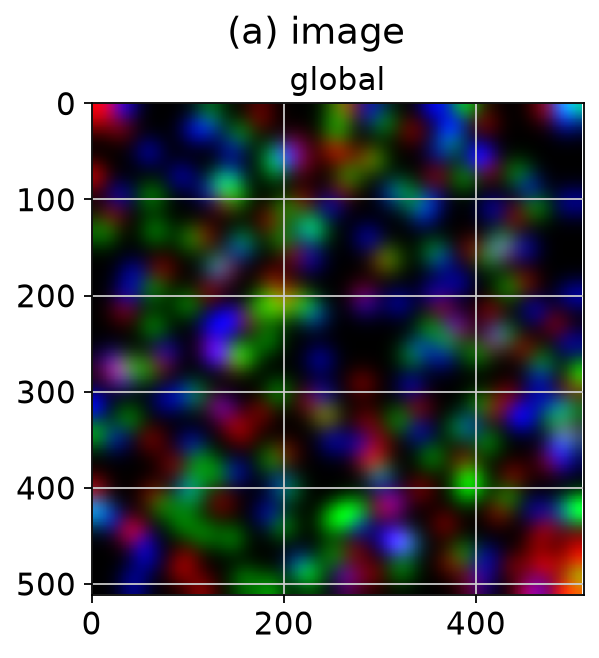

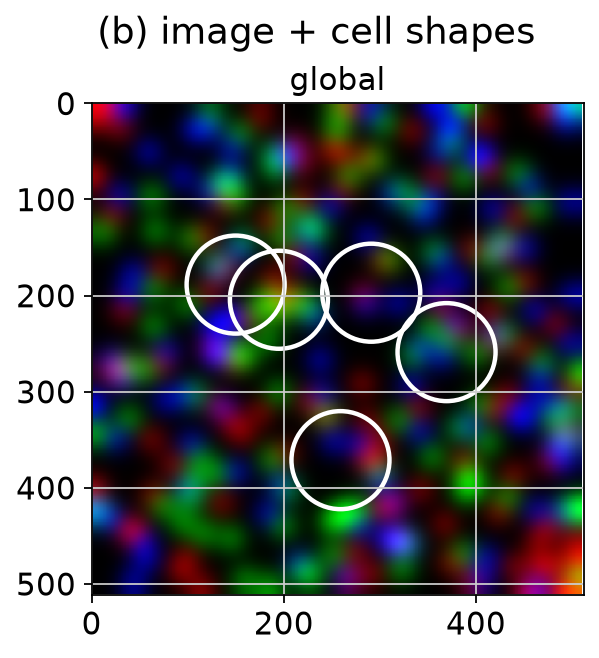

/opt/env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/opt/env/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/env/lib/python3.12/site-packages/spatialdata_plot/pl/render.py:1384: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = ax.scatter(


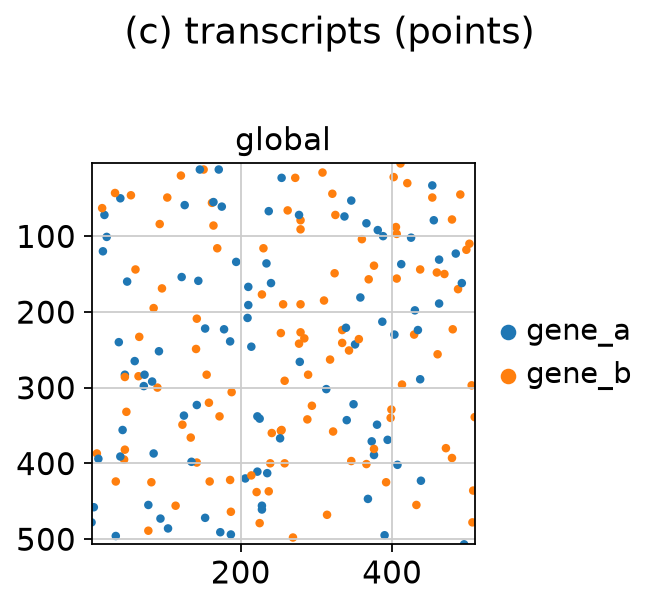

In [84]:
# (a) the image alone
sdata.pl.render_images("blobs_image").pl.show()
plt.suptitle("(a) image")
plt.show()

# (b) image + cell outlines on top
(
    sdata.pl.render_images("blobs_image")
    .pl.render_shapes("blobs_circles", outline_width=2.0, fill_alpha=0.0, outline_color="white")
    .pl.show()
)
plt.suptitle("(b) image + cell shapes")
plt.show()

# (c) transcripts, coloured by gene
sdata.pl.render_points("blobs_points", color="genes", size=8).pl.show()
plt.suptitle("(c) transcripts (points)")
plt.show()

🔬 **TASK 3.1 — Explore the transcripts.** Using the `blobs_points` element (`pts` above):

1. List the unique genes and **count how many transcripts** belong to each (a `.value_counts()`).
2. Render **only the transcripts of one gene** of your choice on top of the image.

💡 **HINT:** `pts` is a (dask) dataframe — `pts["genes"].value_counts().compute()` gives the
counts. To draw one gene, render the image, then `.pl.render_points("blobs_points", color="genes",
groups=["gene_a"])` (use one of *your* gene names).

Unique genes and associated count genes
gene_b    110
gene_a     90
Name: count, dtype: int64


/opt/env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/opt/env/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/env/lib/python3.12/site-packages/spatialdata_plot/pl/render.py:1384: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = ax.scatter(


<function matplotlib.pyplot.show(close=None, block=None)>

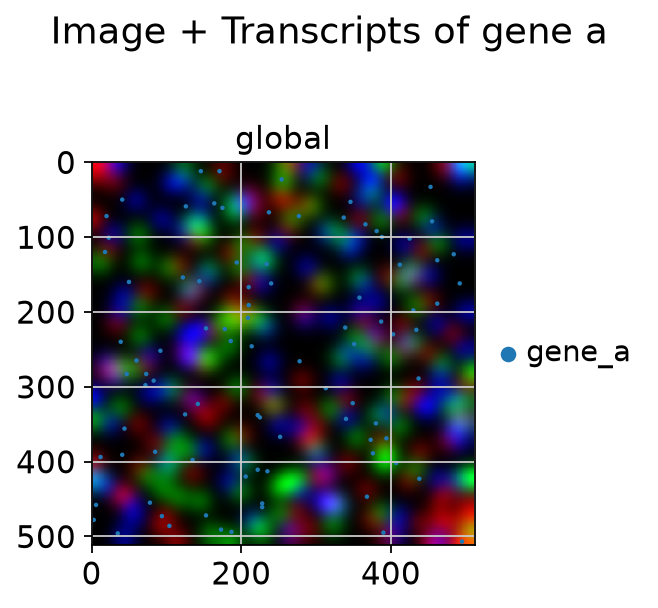

In [96]:
# 1. transcripts per gene  (pts is a dask dataframe -> remember .compute())
print("Unique genes and associated count", pts["genes"].value_counts().compute())

# 2. render only one gene's transcripts on top of the image
gene = "gene_a"
(
    sdata.pl.render_images("blobs_image")
    .pl.render_points("blobs_points", color = "genes", groups = [gene])
    .pl.show()
)
plt.suptitle("Image + Transcripts of gene a")
plt.show

⚠️ **CHECKPOINT.** `blobs` has just two genes — you should get **`gene_b` ≈ 110** and
**`gene_a` ≈ 90** transcripts (200 in total). Your single-gene plot should show a *subset* of the
points in panel (c) above, sitting on top of the image.

❓ **QUESTION.** Map each Level-1 question to the SpatialData element you'd reach for:
*"how many transcripts did the instrument detect?"*, *"where are the cell boundaries the vendor
drew?"*, *"what does the DAPI stain look like here?"*, *"what's the expression of gene X per cell?"*
— which of `points` / `shapes` / `images` / `tables` answers each?

---
## 4. Frameworks — what runs on what

You now know the containers. Each major framework *operates on* one of them. The goal here is to
**orient** (and play a little), not to master — you'll go deep in later levels.

| Framework | Operates on | What it's for | Level |
|---|---|---|---|
| **[Scanpy](https://scanpy.readthedocs.io/)** | AnnData | the scRNA-seq workhorse: QC, clustering, markers, plots | L2 |
| **[Squidpy](https://squidpy.readthedocs.io/)** | AnnData (+ spatial) / SpatialData | spatial graphs, neighbourhood enrichment, ligand–receptor | L2 |
| **[Sopa](https://gustaveroussy.github.io/sopa/)** | SpatialData | image-based ST pipeline: segmentation → cells | L1 |

### 4a. Scanpy → AnnData (pays off in L2)

Everything Scanpy does reads from / writes to AnnData slots. A quick taste: colour the UMAP by
the provided cell labels, then ask which genes mark each group.

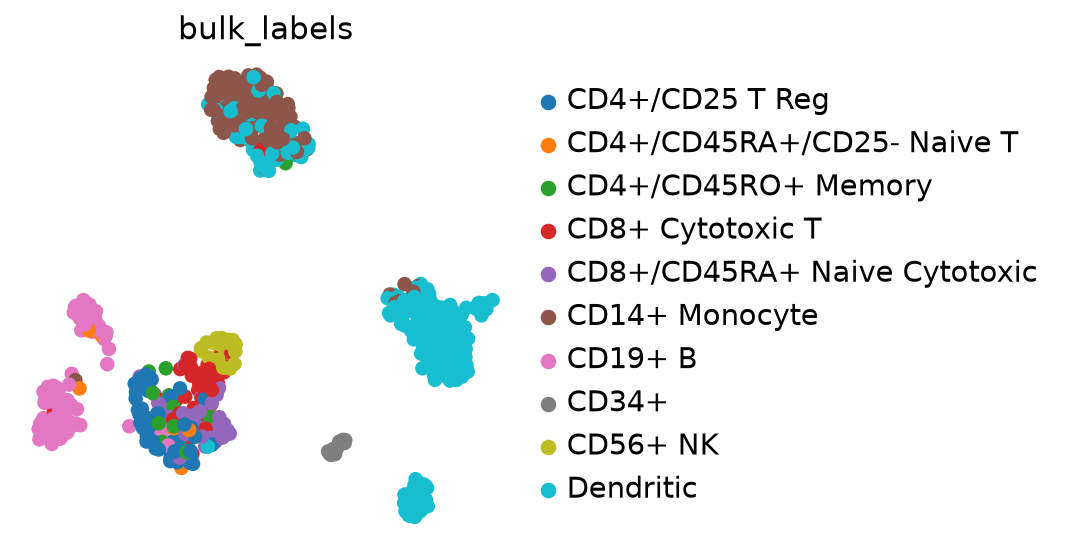

/tmp/slurm_tp185004_437658.tmp/ipykernel_2465999/3526178108.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sc.get.rank_genes_groups_df(a, group=None).groupby("group").head(2).head(10)


,group,names,scores,logfoldchanges,pvals,pvals_adj
0,CD4+/CD25 T Reg,CD3D,11.050765,3.625057,2.173535e-28,1.662755e-25
1,CD4+/CD25 T Reg,CD3E,9.695415,3.007064,3.153547e-22,8.041544e-20
765,CD4+/CD45RA+/CD25- Naive T,ITM2A,4.023366,3.679498,5.737212e-05,4.388967e-02
766,CD4+/CD45RA+/CD25- Naive T,CD3D,2.964771,2.616447,3.029084e-03,3.185709e-01
1530,CD4+/CD45RO+ Memory,CD3D,5.391661,3.139899,6.980956e-08,2.670216e-05
1531,CD4+/CD45RO+ Memory,AES,4.866585,2.248368,1.135433e-06,1.085758e-04
2295,CD8+ Cytotoxic T,CCL5,9.581667,4.682098,9.549102e-22,7.305063e-19
2296,CD8+ Cytotoxic T,NKG7,9.477640,4.543889,2.600981e-21,9.948753e-19
3060,CD8+/CD45RA+ Naive Cytotoxic,CD7,7.683407,3.001546,1.549121e-14,1.692968e-12
3061,CD8+/CD45RA+ Naive Cytotoxic,CD3D,7.582212,3.017596,3.397113e-14,3.248489e-12


In [97]:
a = sc.datasets.pbmc68k_reduced()
sc.pl.umap(a, color="bulk_labels", show=False)
plt.show()

sc.tl.rank_genes_groups(a, "bulk_labels", method="wilcoxon")
sc.get.rank_genes_groups_df(a, group=None).groupby("group").head(2).head(10)

🔬 **TASK 4.1 — Play with Scanpy.** Re-draw the UMAP, but colour it by something else: either a
**gene** (use any name from `a.var_names`, e.g. `a.var_names[0]`) or a **QC metric** like
`"n_genes"`. One line.

💡 **HINT:** `sc.pl.umap(a, color="<gene-or-obs-column>")`.

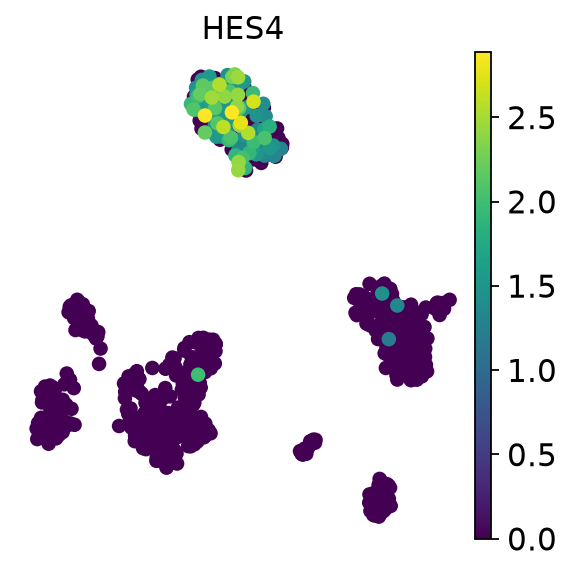

<function matplotlib.pyplot.show(close=None, block=None)>

In [102]:
# colour the UMAP by a gene or a QC metric of your choice
sc.pl.umap(a, color = a.var_names[0])
plt.show

### 4b. Squidpy → spatial neighbourhoods (pays off in L2)

Squidpy adds the *spatial* dimension: it builds a **graph of which cells are physically near
each other**, then lets you ask spatial questions. It ships a real **MERFISH** dataset
(mouse hypothalamus) — image-based spatial transcriptomics, just like the project's data. We
take one tissue slice, build the spatial neighbour graph, and plot cells in space coloured by
type. *(The first run downloads ~50 MB to the cache we set in §0; after that it loads instantly,
so everyone can run this without waiting on each other.)*

INFO     Downloading merfish.h5ad from https://exampledata.scverse.org/squidpy/merfish.h5ad                        


  0%|                                              | 0.00/51.6M [00:00<?, ?B/s]

slice Bregma=-14.000000000000002: 6605 cells × 161 genes; spatial coords in .obsm['spatial']
INFO     Creating graph using `None` transform and `1` libraries.                                                  
spatial graph keys: ['spatial_connectivities', 'spatial_distances']


/opt/env/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:979: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


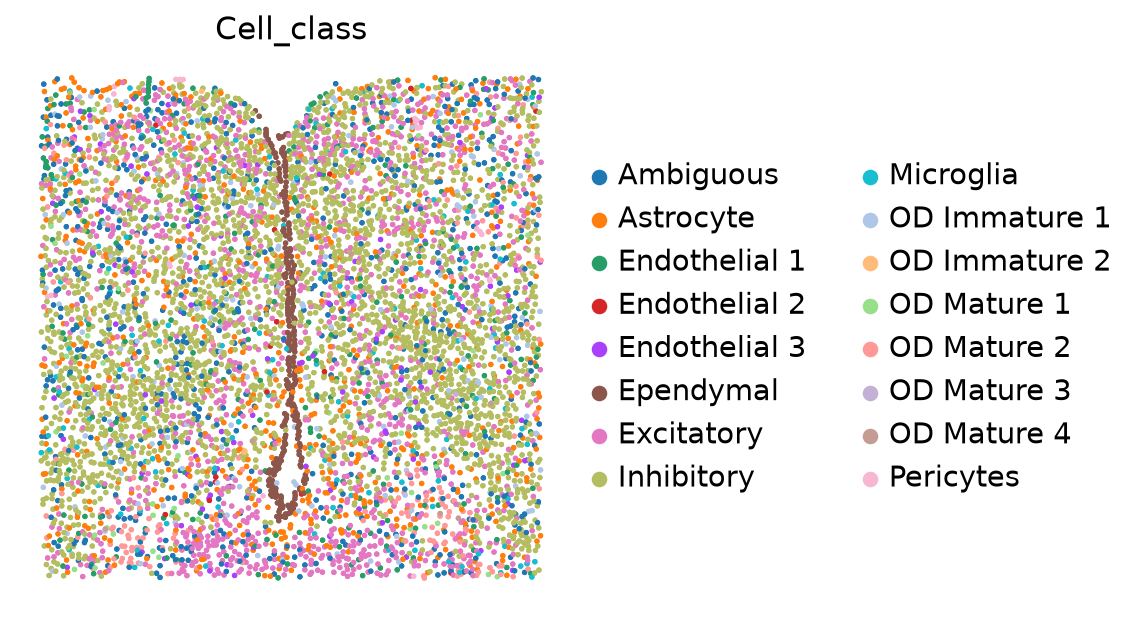

In [106]:
merfish = sq.datasets.merfish()
# the object stacks many coronal slices (one per `Bregma` value); take the largest one
bregma = merfish.obs["Bregma"].value_counts().index[0]
sl = merfish[merfish.obs["Bregma"] == bregma].copy()
print(f"slice Bregma={bregma}: {sl.n_obs} cells × {sl.n_vars} genes; spatial coords in .obsm['spatial']")

# build the spatial neighbour graph (each cell linked to its 6 nearest neighbours) -> lands in .obsp
sq.gr.spatial_neighbors_knn(sl, n_neighs=6)
print("spatial graph keys:", [k for k in sl.obsp.keys()])

sq.pl.spatial_scatter(sl, color="Cell_class", shape=None, size=8, figsize=(7, 7))
plt.show()

That spatial graph (`.obsp["spatial_connectivities"]`) is the foundation for the **niche** and
**neighbourhood-enrichment** analyses you'll run in Level 2 — we won't compute those here.

❓ **QUESTION.** A spatial neighbour graph and an expression-kNN graph (§1) are *both* cell × cell
objects in `.obsp`. What is different about **how each edge is decided** — physical distance on
the slide vs. similarity in gene-expression space?

### 4c. Sopa → from images to cells (pays off in L1)

Sopa drives the **Level-1** pipeline: it takes a raw SpatialData object (image + transcripts) and
**segments it into cells** (Cellpose / Baysor / Proseg), then aggregates transcripts per cell.
Here we just generate Sopa's built-in **toy** SpatialData and confirm it's the same kind of object
you met in §3 — image + transcripts — *without* running any segmentation (that's Level 1's job).

In [117]:
toy_sd = sopa.io.toy_dataset(length=512, cell_density=1e-3)
print(type(toy_sd).__name__, "with elements:")
print("  images:", list(toy_sd.images.keys()))
print("  points:", list(toy_sd.points.keys()))
print("  shapes:", list(toy_sd.shapes.keys()))
print("  tables:", list(toy_sd.tables.keys()))
toy_sd

[INFO] (sopa.utils.data) Image of size (4, 512, 512) with 256 cells and 100 transcripts per cell


SpatialData with elements:
  images: ['image', 'he_image']
  points: ['transcripts']
  shapes: ['cells']
  tables: []


SpatialData object
├── Images
│     ├── 'he_image': DataTree[cyx] (3, 256, 256), (3, 128, 128), (3, 64, 64)
│     └── 'image': DataArray[cyx] (4, 512, 512)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 5) (2D points)
└── Shapes
      └── 'cells': GeoDataFrame shape: (256, 1) (2D shapes)
with coordinate systems:
    ▸ 'global', with elements:
        he_image (Images), image (Images), transcripts (Points), cells (Shapes)
    ▸ 'microns', with elements:
        transcripts (Points)

The Level-1 segmentation chain you'll run is, conceptually:

```
make_transcript_patches  →  segmentation.{cellpose, baysor, proseg}  →  aggregate
        (tile it)               (find cell boundaries)                 (count transcripts/cell)
```

i.e. *image + transcripts (SpatialData)* → *cell shapes* → *a cell × gene table (AnnData)* —
turning the spatial object of §3 into the single-cell object of §1.

---
## 5. Capstone — right slot, right tool

🔬 **TASK 5.1 — Put it together.** For each artifact below, decide **(i)** which container +
slot it belongs in and **(ii)** which framework you'd use to work with it. Fill in the dictionary
and run the cell to print your answer key.

Artifacts:
1. a 2-D UMAP embedding of cells
2. a cell × cell nearest-neighbour graph
3. a raw counts matrix (cells × genes)
4. a DAPI microscope image of a tissue section
5. a table of individual transcript molecules (x, y, gene)
6. per-cell QC metrics (total counts, % mito)

💡 **HINT:** revisit the tables in §1 and §3. "Slot" answers look like `AnnData.obsm`,
`AnnData.obsp`, `AnnData.X`, `SpatialData.images`, `SpatialData.points`, `AnnData.obs`. Some
artifacts have **more than one reasonable framework** — that's expected, not a mistake.

In [120]:
# Fill in (slot, framework) for each artifact, then run to print your key.
answers = {
    "1. UMAP embedding": ("AnnData.obsm", "Scanpy"),
    "2. cell-cell kNN graph": ("AnnData.obsp", "Scanpy"),
    "3. raw counts matrix": ("AnnData.X", "Scanpy"),
    "4. DAPI image": ("SpatialData.images", "Squidpy"),
    "5. transcript molecules": ("SpatialData.points", "Squidpy"),
    "6. per-cell QC metrics": ("AnnData.obs", "Scanpy"),
}
for k, (slot, fw) in answers.items():
    print(f"{k:28s} -> {slot} | {fw}")

1. UMAP embedding            -> AnnData.obsm | Scanpy
2. cell-cell kNN graph       -> AnnData.obsp | Scanpy
3. raw counts matrix         -> AnnData.X | Scanpy
4. DAPI image                -> SpatialData.images | Squidpy
5. transcript molecules      -> SpatialData.points | Squidpy
6. per-cell QC metrics       -> AnnData.obs | Scanpy


---
## Where this is heading

You can now read and build the core containers and match each to its framework. That's the
foundation for the graded levels:

- **Level 1 — raw spatial → clean cells.** Load a real **SpatialData** object straight off the
  instrument, QC it, and use **Sopa** to segment cells and compare strategies.
- **Level 2 — cells → tissue architecture.** Annotate a cohort **AnnData** with **Scanpy**, then
  use **Squidpy** to find spatial niches and cell–cell communication.
- **Level 3 — your own question**, bringing in the **MuData** multiome (RNA + ATAC).

Nothing here was specific to any one dataset — that's the point. When the real brain data arrives
in Level 1, you'll already know where every piece lives.

In [122]:
# Reproducibility: record the exact package versions used.
import session_info2

session_info2.session_info(os=True, cpu=True)

Package,Version
spatialdata,0.7.3
pandas,2.3.3
numpy,2.0.2
scipy,1.16.3
matplotlib,3.11.0
anndata,0.12.17
scanpy,1.12.1
mudata,0.3.8
spatialdata-plot,0.4.0
squidpy,1.8.2
